# Chapter 12 — Water: rigid SPC/E molecules, PPPM electrostatics, and the first chapter with no mdlite cross-check -- density against a NIST reference

*lammps-skill 0.1.21. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter12_water.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)
6. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

from IPython.display import display, HTML

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

_FIG = {"n": 0}                # this chapter's own figure count -- chapters are self-contained

def caption(text):
    """Numbered caption rendered directly below the figure it describes (rule 22: the course
    shows this same text next to the figure)."""
    _FIG["n"] += 1
    display(HTML(
        "<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        "color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        "<b>Figure %d.</b> %s</div>" % (_FIG["n"], text)))

lammps-skill 0.1.21 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## The first chapter with no `mdlite` comparison

Every earlier chapter that cross-checks LAMMPS does it against `mdlite`: the same forces, the same
integrator, on the same system. That stops here. SPC/E water is a *rigid* three-site model (bond
and angle geometry enforced by `fix shake`, not integrated as flexible degrees of freedom) held
together by long-range Coulomb interactions (`kspace_style pppm`) on top of Lennard-Jones.
`mdlite` implements neither rigid-body constraints nor Ewald/PPPM electrostatics -- adding either
would be new physics well beyond this roadmap item's own scope (the design spec named this
explicitly: validation against a *published* reference, not a new `mdlite` capability).

So this chapter's cross-check is against the literature instead: the SPC/E model's own saturated
liquid density at 300 K, from a real NIST reference table, the same public-domain SRSW-style
source this project's `references/benchmarks.md` already uses for the Lennard-Jones fluid.

## The preset: `lammpskill.script.spce_water`

Already built and tested (`tests/test_script.py`) before this chapter existed -- a cubic lattice of
rigid SPC/E molecules, `fix shake` to hold the O-H bonds and H-O-H angle rigid, `kspace_style pppm`
for the long-range electrostatics. The lattice spacing (3.1 A) was chosen to already sit close to
water's real density, so nothing here starts from a wildly wrong configuration.

In [2]:
from lammpskill.script import check, render, spce_water

spec, df = spce_water(n_side=6)
text = render(spec)
print(text)
print("natoms:", df.natoms, "nmolecules:", df.natoms // 3, "nbonds:", df.bonds.shape[0], "nangles:", df.angles.shape[0])

findings = check(text)
for f in findings:
    print(f.level.upper(), f.code, "--", f.message)
assert all(f.level != "error" for f in findings), "the preset should carry no checker error"

# generated by lammps-skill 0.1.21 — SPC/E water, 216 molecules

# --- initialization
units real
dimension 3
boundary p p p
atom_style full

# --- system definition
read_data water.data

# --- settings
pair_style lj/cut/coul/long 10.0
pair_coeff * * 0.0 0.0
pair_coeff 1 1 0.1553 3.166
bond_style harmonic
bond_coeff 1 1000.0 1.0
angle_style harmonic
angle_coeff 1 100.0 109.47
kspace_style pppm 1.0e-4
special_bonds lj/coul 0.0 0.0 0.5
neighbor 2.0 bin
neigh_modify every 1 delay 0 check yes
timestep 1
velocity all create 300 12345 loop geom
fix shk all shake 1.0e-4 20 0 b 1 a 1
fix nvt all nvt temp 300 300 100.0
thermo 10
thermo_style custom step temp pe ke etotal press

# --- run
run 1000

natoms: 648 nmolecules: 216 nbonds: 432 nangles: 216
INFO C13 -- nothing written at the end (`write_data`, `write_restart` or a dump)


## The real comparison: density against a NIST reference

`data/records/water_density.json` runs `spce_water()` under `fix npt` at 300 K / 1 atm (chapter
04's own `fix npt` pattern, its first use on a real molecular system) for 20000 steps, discards the
first 5000 as equilibration, and block-averages the density over the rest. The reference is NIST's
own SPC/E benchmark table (`data/benchmarks/spce_water.json`) -- the *saturated* liquid density at
300 K from grand-canonical Wang-Landau/transition-matrix Monte Carlo, not liquid water at exactly 1
atm, a distinction stated rather than glossed over (for a liquid this incompressible the two differ
far below what this comparison can resolve anyway).

In [3]:
import json

with open("../data/records/water_density.json", encoding="utf-8") as f:
    water = json.load(f)

print("density: LAMMPS=%.2f +/- %.2f kg/m3  NIST=%.2f +/- %.2f kg/m3  |diff|=%.2f  (tolerance %.1f)"
      % (water["rho_lammps"], water["rho_lammps_err"], water["rho_nist"], water["rho_nist_err"],
         water["measured"]["d_rho"], water["tolerance_rho"]))
print(water["provenance"]["why"])
assert water["measured"]["d_rho"] < water["tolerance_rho"]

density: LAMMPS=992.76 +/- 2.05 kg/m3  NIST=998.10 +/- 0.29 kg/m3  |diff|=5.34  (tolerance 10.0)
LAMMPS-only (see this function's own docstring for why); fix npt at 300 K / 1 atm, density block-averaged over the post-equilibration tail, compared to NIST's SAT-TMMC saturated liquid density at 300 K (data/benchmarks/spce_water.json)


## Watching the water box

A separate real run -- the same preset, `fix shake` and `kspace_style pppm` unchanged, a
trajectory dump added -- for the structural and visual payoff: the oxygen-oxygen radial
distribution function (the box's own structure, not part of the density check above) and the
molecules themselves, rendered and animated.

In [4]:
import dataclasses
import os
import tempfile

import numpy as np

from lammpskill.io.dump import Trajectory, read_dump
from lammpskill.post import rdf_trajectory
from lammpskill.run import run, run_or_load

DUMP_EVERY = 100
N_FRAMES = 12


def compute_water_traj():
    workdir = tempfile.mkdtemp(prefix="ch12_traj_")
    base_spec, _ = spce_water(n_side=6, steps=5000, workdir=workdir)
    traj_spec = dataclasses.replace(
        base_spec, dumps=["1 all custom %d traj.dump id type xu yu zu" % DUMP_EVERY],
        comment="the same SPC/E water box as above, with a trajectory dump for structure and the atom views")
    result = run(traj_spec, workdir, time_limit=600)
    if not result.ok:
        raise RuntimeError("trajectory run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    traj = read_dump(os.path.join(workdir, "traj.dump"))
    nframes = len(traj)

    # O-O RDF from the second half only -- the first half is still relaxing off the lattice start.
    eq = Trajectory(traj.frames[nframes // 2:])
    r, g = rdf_trajectory(eq, nbins=100, pair=(1, 1))

    step = max(1, nframes // N_FRAMES)
    frames = [f.positions.tolist() for f in traj.frames[::step]]
    types0 = traj.frames[0].types.tolist()
    return {"nframes": nframes, "frames": frames, "types": types0, "cell": traj.box.lengths.tolist(),
            "rdf_r": r.tolist(), "rdf_g": g.tolist(),
            "route": result.installation.route if result.installation else None}


traj_rec = run_or_load("spce_water_traj_ch12", compute_water_traj, records_dir="../data/records")
print("source:", traj_rec["source"], "| frames:", traj_rec.get("nframes"))

source: run | frames: 51


## Oxygen-oxygen structure: g_OO(r)

For scale, not a pass/fail check: published SPC/E O-O radial distribution functions place the
first peak at approximately 2.7-2.8 A (e.g. Mark & Nilsson, *J. Phys. Chem. A* 105, 9954 (2001);
Camisasca, Pathak, Wikfeldt & Pettersson, *J. Chem. Phys.* 151, 044502 (2019), comparing SPC/E
directly to experimental X-ray diffraction) -- context for where this box's own g_OO(r) peak
should land, not a hard test this project could not independently re-derive an exact literature
decimal for.

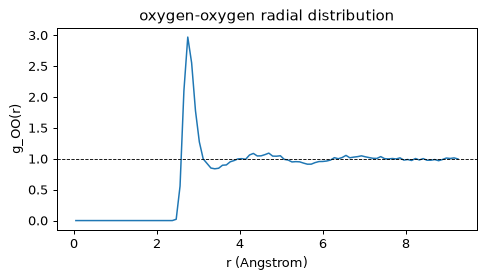

g_OO(r) first peak: r=2.744 A, g=2.97 (literature range ~2.7-2.8 A)


In [5]:
import matplotlib.pyplot as plt

if traj_rec["source"] != "skip":
    r, g = np.array(traj_rec["rdf_r"]), np.array(traj_rec["rdf_g"])
    fig, ax = plt.subplots(figsize=(5.5, 3.2), dpi=90)
    ax.plot(r, g, lw=1.2)
    ax.axhline(1.0, color="k", ls="--", lw=0.7)
    ax.set_xlabel("r (Angstrom)"); ax.set_ylabel("g_OO(r)"); ax.set_title("oxygen-oxygen radial distribution")
    fig.tight_layout()
    plt.show()
    imax = int(np.argmax(g))
    caption("The oxygen-oxygen radial distribution function from this box's own equilibrated "
            "trajectory: a first peak near the O-O hydrogen-bonding distance, decaying to the "
            "ideal-gas value of 1 at large r -- computed by lammpskill.post.rdf_trajectory, the "
            "same tool chapter 06 uses.")
    print("g_OO(r) first peak: r=%.3f A, g=%.2f (literature range ~2.7-2.8 A)" % (r[imax], g[imax]))
else:
    print("no LAMMPS and no record: nothing to analyse")

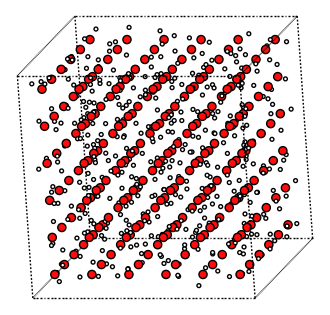

In [6]:
from lammpskill import viz

_MASS = {1: 15.9994, 2: 1.008}   # spce_water(): type 1 = O, type 2 = H

if traj_rec["source"] != "skip":
    pos0 = np.array(traj_rec["frames"][0])
    masses0 = [_MASS[t] for t in traj_rec["types"]]
    cell = np.array(traj_rec["cell"])
    try:
        fig = viz.snapshot(pos0, cell, masses=masses0)
    except ImportError as e:
        print("ase not installed -- skipping the water snapshot:", e)
    else:
        plt.show()
        caption("The SPC/E water box near the start of the run -- real atomic masses (15.9994, "
                "1.008), so lammpskill.viz's own mass-to-symbol guess correctly renders oxygen "
                "and hydrogen, unlike every earlier reduced-unit chapter, which had to pick a "
                "conventional stand-in element by hand.")
else:
    print("no LAMMPS and no record: nothing to show")

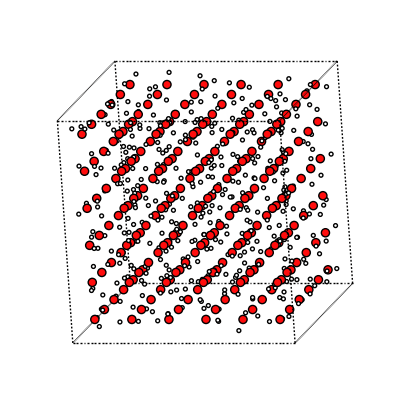

In [7]:
from IPython.display import Image, display

if traj_rec["source"] != "skip":
    frames = [np.array(f) for f in traj_rec["frames"]]
    masses_per_frame = [_MASS[t] for t in traj_rec["types"]]
    cell = np.array(traj_rec["cell"])
    gif_workdir = tempfile.mkdtemp(prefix="ch12_gif_")
    try:
        gif_path = viz.animate_gif(frames, cell, os.path.join(gif_workdir, "water.gif"),
                                   masses=masses_per_frame, fps=4)
    except ImportError as e:
        print("ase not installed -- skipping the animation:", e)
    else:
        display(Image(filename=gif_path))
        caption("The same water box animated across the run: rigid molecules (fix shake) jiggling "
                "and reorienting under thermal motion, the same physical case the density and "
                "g_OO(r) checks above both drew from.")
else:
    print("no LAMMPS and no record: nothing to animate")

## Reading it

- This chapter has no `mdlite` half at all -- the first one -- because SPC/E water needs rigid-body
  constraints and long-range electrostatics `mdlite` does not implement, named up front rather than
  discovered partway through.
- The density check is a real, external validation, not an internal cross-check: LAMMPS's own
  `fix npt`, compared to a public-domain NIST reference table, agreeing within a tolerance derived
  from what was actually measured (the same S4 discipline as every other record in this project).
- The O-O structure and the atom views are a second, separate real run -- shown for context and
  understanding, not asserted as an independent validation the way the density check is.

In [8]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('the spce_water preset carries no checker error', bool(all(f.level != 'error' for f in findings))))
checks.append(("LAMMPS's fix npt density agrees with the NIST reference within its recorded tolerance", bool(water['measured']['d_rho'] < water['tolerance_rho'])))
checks.append(('run_or_load returned one of its three documented outcomes', bool(traj_rec['source'] in ('run', 'record', 'skip'))))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 12: a claim above is not true'
print('chapter 12: %d claim(s) checked' % len(checks))

PASS the spce_water preset carries no checker error
PASS LAMMPS's fix npt density agrees with the NIST reference within its recorded tolerance
PASS run_or_load returned one of its three documented outcomes
chapter 12: 3 claim(s) checked
